# 🎬 Social Video Audience Sentiment Intelligence
### End-to-End ML Pipeline —

**Tech stack:** Python · MongoDB · DVC · LightGBM · TF-IDF · MLflow / DagsHub · Flask

---

**Pipeline stages**
1. Environment & Secrets setup
2. Project structure scaffold
3. Stage 1 — Data Ingestion
4. Stage 2 — Data Pre-processing
5. Stage 3 — Model Building (TF-IDF + LightGBM)
6. Stage 4 — Model Evaluation + MLflow logging
7. Stage 5 — Model Registration
8. Flask API (local test inside Colab)


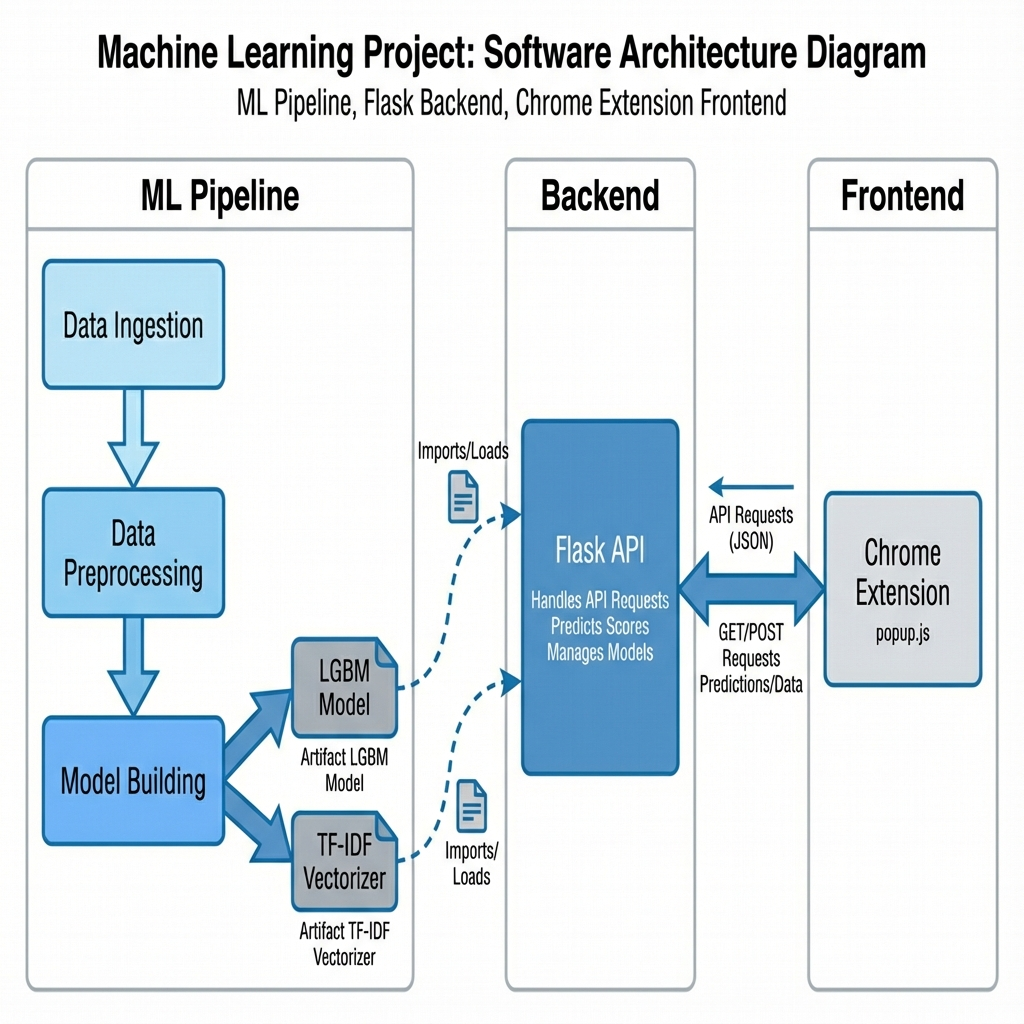

In [23]:
from IPython.display import Image, display

display(Image('/content/architecture_diagram (3).jpg'))

## 📦 Step 1 — Install Dependencies

> Restart the Colab runtime if prompted after this cell.

In [1]:
# Install all required packages
!pip install -q \
    lightgbm==4.5.0 \
    mlflow==2.17.0 \
    'dvc==3.53.0' \
    'dvc[s3]' \
    nltk==3.9.1 \
    wordcloud==1.9.3 \
    Flask==3.0.3 \
    Flask-Cors==5.0.0 \
    pymongo \
    seaborn \
    dagshub

print('✅ All packages installed.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.8/452.8 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44

## 🔐 Step 2 — Set Environment Variables (from Colab Secrets)

Go to **Colab → Secrets** (key icon in left panel) and add:
- `MONGO_DB_URL`
- `MLFLOW_TRACKING_URI`
- `MLFLOW_TRACKING_USERNAME`
- `MLFLOW_TRACKING_PASSWORD`

In [2]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ──────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ updated

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside Colab
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")


✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


## 🗂️ Step 3 — Create Project Structure

In [3]:
import os

# All directories needed by the pipeline
DIRS = ['src/data', 'src/model', 'data/raw', 'data/interim', 'flask_api', 'artifacts']

for d in DIRS:
    os.makedirs(d, exist_ok=True)

# Make src packages importable
for pkg in ['src', 'src/data', 'src/model']:
    init = os.path.join(pkg, '__init__.py')
    if not os.path.exists(init):
        open(init, 'w').close()

print('✅ Project structure ready.')


✅ Project structure ready.


## ⚙️ Step 4 — Write `params.yaml`

In [4]:
params_content = """\
data_ingestion:
  test_size: 0.20          # 20% held-out test set

model_building:
  ngram_range: [1, 3]      # unigrams -> trigrams for TF-IDF
  max_features: 1000       # vocabulary size cap
  learning_rate: 0.09      # LightGBM learning rate
  max_depth: 20            # maximum tree depth
  n_estimators: 367        # number of boosting rounds
"""

with open('params.yaml', 'w') as f:
    f.write(params_content)

print('✅ params.yaml written.')


✅ params.yaml written.


## 🔄 Step 5 — Write `dvc.yaml` (Pipeline DAG)

In [5]:
dvc_content = """\
stages:
  data_ingestion:
    cmd: python src/data/data_ingestion.py
    deps:
      - src/data/data_ingestion.py
    params:
      - data_ingestion.test_size
    outs:
      - data/raw:
          cache: false

  data_preprocessing:
    cmd: python src/data/data_preprocessing.py
    deps:
      - data/raw/train.csv
      - data/raw/test.csv
      - src/data/data_preprocessing.py
    outs:
      - data/interim:
          cache: false

  model_building:
    cmd: python src/model/model_building.py
    deps:
      - data/interim/train_processed.csv
      - src/model/model_building.py
    params:
      - model_building.max_features
      - model_building.ngram_range
      - model_building.learning_rate
      - model_building.max_depth
      - model_building.n_estimators
    outs:
      - lgbm_model.pkl:
          cache: false
      - tfidf_vectorizer.pkl:
          cache: false
"""

with open('dvc.yaml', 'w') as f:
    f.write(dvc_content)

print('✅ dvc.yaml written.')


✅ dvc.yaml written.


## 📝 Step 6 — Write All Pipeline Source Files (`.py`)

The cells below write each stage module to disk so they can be
executed independently **and** via `dvc repro`.

In [6]:
# ── Stage 1 – data_ingestion.py ─────────────────────────────────────────────────
_src = """\
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import yaml
import logging

# Logging configuration
logger = logging.getLogger('data_ingestion')
logger.setLevel(logging.DEBUG)

console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)

file_handler = logging.FileHandler('errors.log')
file_handler.setLevel(logging.ERROR)

formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)

logger.addHandler(console_handler)
logger.addHandler(file_handler)

def load_params(params_path: str) -> dict:
    \"\"\"Load parameters from a YAML file.\"\"\"
    try:
        with open(params_path, 'r') as file:
            params = yaml.safe_load(file)
        logger.debug('Parameters retrieved from %s', params_path)
        return params
    except FileNotFoundError:
        logger.error('File not found: %s', params_path)
        raise
    except yaml.YAMLError as e:
        logger.error('YAML error: %s', e)
        raise
    except Exception as e:
        logger.error('Unexpected error: %s', e)
        raise

def load_data(data_url: str) -> pd.DataFrame:
    \"\"\"Load data from a CSV file.\"\"\"
    try:
        df = pd.read_csv(data_url)
        logger.debug('Data loaded from %s', data_url)
        return df
    except pd.errors.ParserError as e:
        logger.error('Failed to parse the CSV file: %s', e)
        raise
    except Exception as e:
        logger.error('Unexpected error occurred while loading the data: %s', e)
        raise

def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    \"\"\"Preprocess the data by handling missing values, duplicates, and empty strings.\"\"\"
    try:
        # Removing missing values
        df.dropna(inplace=True)
        # Removing duplicates
        df.drop_duplicates(inplace=True)
        # Removing rows with empty strings
        df = df[df['clean_comment'].str.strip() != '']

        logger.debug('Data preprocessing completed: Missing values, duplicates, and empty strings removed.')
        return df
    except KeyError as e:
        logger.error('Missing column in the dataframe: %s', e)
        raise
    except Exception as e:
        logger.error('Unexpected error during preprocessing: %s', e)
        raise

def save_data(train_data: pd.DataFrame, test_data: pd.DataFrame, data_path: str) -> None:
    \"\"\"Save the train and test datasets, creating the raw folder if it doesn't exist.\"\"\"
    try:
        raw_data_path = os.path.join(data_path, 'raw')

        # Create the data/raw directory if it does not exist
        os.makedirs(raw_data_path, exist_ok=True)

        # Save the train and test data
        train_data.to_csv(os.path.join(raw_data_path, \"train.csv\"), index=False)
        test_data.to_csv(os.path.join(raw_data_path, \"test.csv\"), index=False)

        logger.debug('Train and test data saved to %s', raw_data_path)
    except Exception as e:
        logger.error('Unexpected error occurred while saving the data: %s', e)
        raise

def main():
    try:
        # Load parameters from the params.yaml in the root directory
        params = load_params(params_path=os.path.join(os.path.dirname(os.path.abspath(__file__)), '../../params.yaml'))
        test_size = params['data_ingestion']['test_size']

        # Load data from the specified URL
        df = load_data(data_url='https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

        # Preprocess the data
        final_df = preprocess_data(df)

        # Split the data into training and testing sets
        train_data, test_data = train_test_split(final_df, test_size=test_size, random_state=42)

        # Save the split datasets and create the raw folder if it doesn't exist
        save_data(train_data, test_data, data_path=os.path.join(os.path.dirname(os.path.abspath(__file__)), '../../data'))

    except Exception as e:
        logger.error('Failed to complete the data ingestion process: %s', e)
        print(f\"Error: {e}\")

if __name__ == '__main__':
    main()

"""

import os; os.makedirs(os.path.dirname("src/data/data_ingestion.py") or ".", exist_ok=True)
with open("src/data/data_ingestion.py", "w") as _f:
    _f.write(_src)

print("✅ src/data/data_ingestion.py written.")


✅ src/data/data_ingestion.py written.


In [7]:
# ── Stage 2 – data_preprocessing.py ─────────────────────────────────────────────────
_src = """\
import numpy as np
import pandas as pd
import os
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import logging


# logging configuration
logger = logging.getLogger('data_preprocessing')
logger.setLevel('DEBUG')

console_handler = logging.StreamHandler()
console_handler.setLevel('DEBUG')

file_handler = logging.FileHandler('preprocessing_errors.log')
file_handler.setLevel('ERROR')

formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)

logger.addHandler(console_handler)
logger.addHandler(file_handler)


# Download required NLTK data
nltk.download('wordnet')
nltk.download('stopwords')



# Define the preprocessing function
def preprocess_comment(comment):
    \"\"\"Apply preprocessing transformations to a comment.\"\"\"
    try:
        # Convert to lowercase
        comment = comment.lower()

        # Remove trailing and leading whitespaces
        comment = comment.strip()

        # Remove newline characters
        comment = re.sub(r'\\n', ' ', comment)

        # Remove non-alphanumeric characters, except punctuation
        comment = re.sub(r'[^A-Za-z0-9\\s!?.,]', '', comment)

        # Remove stopwords but retain important ones for sentiment analysis
        stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
        comment = ' '.join([word for word in comment.split() if word not in stop_words])

        # Lemmatize the words
        lemmatizer = WordNetLemmatizer()
        comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

        return comment
    except Exception as e:
        logger.error(f\"Error in preprocessing comment: {e}\")
        return comment



def normalize_text(df):
    \"\"\"Apply preprocessing to the text data in the dataframe.\"\"\"
    try:
        df['clean_comment'] = df['clean_comment'].apply(preprocess_comment)
        logger.debug('Text normalization completed')
        return df
    except Exception as e:
        logger.error(f\"Error during text normalization: {e}\")
        raise




def save_data(train_data: pd.DataFrame, test_data: pd.DataFrame, data_path: str) -> None:
    \"\"\"Save the processed train and test datasets.\"\"\"
    try:
        interim_data_path = os.path.join(data_path, 'interim')
        logger.debug(f\"Creating directory {interim_data_path}\")

        os.makedirs(interim_data_path, exist_ok=True)  # Ensure the directory is created
        logger.debug(f\"Directory {interim_data_path} created or already exists\")

        train_data.to_csv(os.path.join(interim_data_path, \"train_processed.csv\"), index=False)
        test_data.to_csv(os.path.join(interim_data_path, \"test_processed.csv\"), index=False)

        logger.debug(f\"Processed data saved to {interim_data_path}\")
    except Exception as e:
        logger.error(f\"Error occurred while saving data: {e}\")
        raise



def main():
    try:
        logger.debug(\"Starting data preprocessing...\")

        # Fetch the data from data/raw
        train_data = pd.read_csv('./data/raw/train.csv')
        test_data = pd.read_csv('./data/raw/test.csv')
        logger.debug('Data loaded successfully')

        # Preprocess the data
        train_processed_data = normalize_text(train_data)
        test_processed_data = normalize_text(test_data)

        # Save the processed data
        save_data(train_processed_data, test_processed_data, data_path='./data')
    except Exception as e:
        logger.error('Failed to complete the data preprocessing process: %s', e)
        print(f\"Error: {e}\")

if __name__ == '__main__':
    main()

"""

import os; os.makedirs(os.path.dirname("src/data/data_preprocessing.py") or ".", exist_ok=True)
with open("src/data/data_preprocessing.py", "w") as _f:
    _f.write(_src)

print("✅ src/data/data_preprocessing.py written.")


✅ src/data/data_preprocessing.py written.


In [8]:
# ── Stage 3 – model_building.py ─────────────────────────────────────────────────
_src = """\
import numpy as np
import pandas as pd
import os
import pickle
import yaml
import logging
import lightgbm as lgb
from sklearn.feature_extraction.text import TfidfVectorizer


# logging configuration
logger = logging.getLogger('model_building')
logger.setLevel('DEBUG')

console_handler = logging.StreamHandler()
console_handler.setLevel('DEBUG')

file_handler = logging.FileHandler('model_building_errors.log')
file_handler.setLevel('ERROR')

formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)

logger.addHandler(console_handler)
logger.addHandler(file_handler)


def load_params(params_path: str) -> dict:
    \"\"\"Load parameters from a YAML file.\"\"\"
    try:
        with open(params_path, 'r') as file:
            params = yaml.safe_load(file)
        logger.debug('Parameters retrieved from %s', params_path)
        return params
    except FileNotFoundError:
        logger.error('File not found: %s', params_path)
        raise
    except yaml.YAMLError as e:
        logger.error('YAML error: %s', e)
        raise
    except Exception as e:
        logger.error('Unexpected error: %s', e)
        raise



def load_data(file_path: str) -> pd.DataFrame:
    \"\"\"Load data from a CSV file.\"\"\"
    try:
        df = pd.read_csv(file_path)
        df.fillna('', inplace=True)  # Fill any NaN values
        logger.debug('Data loaded and NaNs filled from %s', file_path)
        return df
    except pd.errors.ParserError as e:
        logger.error('Failed to parse the CSV file: %s', e)
        raise
    except Exception as e:
        logger.error('Unexpected error occurred while loading the data: %s', e)
        raise



def get_root_directory() -> str:
    \"\"\"Get the root directory (two levels up from this script's location).\"\"\"
    current_dir = os.path.dirname(os.path.abspath(__file__))
    return os.path.abspath(os.path.join(current_dir, '../../'))


def apply_tfidf(train_data: pd.DataFrame, max_features: int, ngram_range: tuple) -> tuple:
    \"\"\"Apply TF-IDF with ngrams to the data.\"\"\"
    try:
        vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)

        X_train = train_data['clean_comment'].values
        y_train = train_data['category'].values

        # Perform TF-IDF transformation
        X_train_tfidf = vectorizer.fit_transform(X_train)

        logger.debug(f\"TF-IDF transformation complete. Train shape: {X_train_tfidf.shape}\")

        # Save the vectorizer in the root directory
        with open(os.path.join(get_root_directory(), 'tfidf_vectorizer.pkl'), 'wb') as f:
            pickle.dump(vectorizer, f)

        logger.debug('TF-IDF applied with trigrams and data transformed')
        return X_train_tfidf, y_train
    except Exception as e:
        logger.error('Error during TF-IDF transformation: %s', e)
        raise



def train_lgbm(X_train: np.ndarray, y_train: np.ndarray, learning_rate: float, max_depth: int, n_estimators: int) -> lgb.LGBMClassifier:
    \"\"\"Train a LightGBM model.\"\"\"
    try:
        best_model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=3,
            metric=\"multi_logloss\",
            is_unbalance=True,
            class_weight=\"balanced\",
            reg_alpha=0.1,  # L1 regularization
            reg_lambda=0.1,  # L2 regularization
            learning_rate=learning_rate,
            max_depth=max_depth,
            n_estimators=n_estimators
        )
        best_model.fit(X_train, y_train)
        logger.debug('LightGBM model training completed')
        return best_model
    except Exception as e:
        logger.error('Error during LightGBM model training: %s', e)
        raise



def save_model(model, file_path: str) -> None:
    \"\"\"Save the trained model to a file.\"\"\"
    try:
        with open(file_path, 'wb') as file:
            pickle.dump(model, file)
        logger.debug('Model saved to %s', file_path)
    except Exception as e:
        logger.error('Error occurred while saving the model: %s', e)
        raise




def main():
    try:
        # Get root directory and resolve the path for params.yaml
        root_dir = get_root_directory()

        # Load parameters from the root directory
        params = load_params(os.path.join(root_dir, 'params.yaml'))
        max_features = params['model_building']['max_features']
        ngram_range = tuple(params['model_building']['ngram_range'])

        learning_rate = params['model_building']['learning_rate']
        max_depth = params['model_building']['max_depth']
        n_estimators = params['model_building']['n_estimators']

        # Load the preprocessed training data from the interim directory
        train_data = load_data(os.path.join(root_dir, 'data/interim/train_processed.csv'))

        # Apply TF-IDF feature engineering on training data
        X_train_tfidf, y_train = apply_tfidf(train_data, max_features, ngram_range)

        # Train the LightGBM model using hyperparameters from params.yaml
        best_model = train_lgbm(X_train_tfidf, y_train, learning_rate, max_depth, n_estimators)

        # Save the trained model in the root directory
        save_model(best_model, os.path.join(root_dir, 'lgbm_model.pkl'))

    except Exception as e:
        logger.error('Failed to complete the feature engineering and model building process: %s', e)
        print(f\"Error: {e}\")


if __name__ == '__main__':
    main()

"""

import os; os.makedirs(os.path.dirname("src/model/model_building.py") or ".", exist_ok=True)
with open("src/model/model_building.py", "w") as _f:
    _f.write(_src)

print("✅ src/model/model_building.py written.")


✅ src/model/model_building.py written.


In [9]:
# ── Stage 4 – model_evaluation.py (MLflow URI from env var) ─────────────────────────────────────────────────
_src = """\
import numpy as np
import pandas as pd
import pickle
import logging
import yaml
import mlflow
import mlflow.sklearn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
from mlflow.models import infer_signature

# logging configuration
logger = logging.getLogger('model_evaluation')
logger.setLevel('DEBUG')

console_handler = logging.StreamHandler()
console_handler.setLevel('DEBUG')

file_handler = logging.FileHandler('model_evaluation_errors.log')
file_handler.setLevel('ERROR')

formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)

logger.addHandler(console_handler)
logger.addHandler(file_handler)


def load_data(file_path: str) -> pd.DataFrame:
    \"\"\"Load data from a CSV file.\"\"\"
    try:
        df = pd.read_csv(file_path)
        df.fillna('', inplace=True)  # Fill any NaN values
        logger.debug('Data loaded and NaNs filled from %s', file_path)
        return df
    except Exception as e:
        logger.error('Error loading data from %s: %s', file_path, e)
        raise


def load_model(model_path: str):
    \"\"\"Load the trained model.\"\"\"
    try:
        with open(model_path, 'rb') as file:
            model = pickle.load(file)
        logger.debug('Model loaded from %s', model_path)
        return model
    except Exception as e:
        logger.error('Error loading model from %s: %s', model_path, e)
        raise


def load_vectorizer(vectorizer_path: str) -> TfidfVectorizer:
    \"\"\"Load the saved TF-IDF vectorizer.\"\"\"
    try:
        with open(vectorizer_path, 'rb') as file:
            vectorizer = pickle.load(file)
        logger.debug('TF-IDF vectorizer loaded from %s', vectorizer_path)
        return vectorizer
    except Exception as e:
        logger.error('Error loading vectorizer from %s: %s', vectorizer_path, e)
        raise


def load_params(params_path: str) -> dict:
    \"\"\"Load parameters from a YAML file.\"\"\"
    try:
        with open(params_path, 'r') as file:
            params = yaml.safe_load(file)
        logger.debug('Parameters loaded from %s', params_path)
        return params
    except Exception as e:
        logger.error('Error loading parameters from %s: %s', params_path, e)
        raise


def evaluate_model(model, X_test: np.ndarray, y_test: np.ndarray):
    \"\"\"Evaluate the model and log classification metrics and confusion matrix.\"\"\"
    try:
        # Predict and calculate classification metrics
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        cm = confusion_matrix(y_test, y_pred)

        logger.debug('Model evaluation completed')

        return report, cm
    except Exception as e:
        logger.error('Error during model evaluation: %s', e)
        raise


def log_confusion_matrix(cm, dataset_name):
    \"\"\"Log confusion matrix as an artifact.\"\"\"
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {dataset_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Save confusion matrix plot as a file and log it to MLflow
    cm_file_path = f'confusion_matrix_{dataset_name}.png'
    plt.savefig(cm_file_path)
    mlflow.log_artifact(cm_file_path)
    plt.close()

def save_model_info(run_id: str, model_path: str, file_path: str) -> None:
    \"\"\"Save the model run ID and path to a JSON file.\"\"\"
    try:
        # Create a dictionary with the info you want to save
        model_info = {
            'run_id': run_id,
            'model_path': model_path
        }
        # Save the dictionary as a JSON file
        with open(file_path, 'w') as file:
            json.dump(model_info, file, indent=4)
        logger.debug('Model info saved to %s', file_path)
    except Exception as e:
        logger.error('Error occurred while saving the model info: %s', e)
        raise


def main():
    mlflow.set_tracking_uri(os.environ.get(\"MLFLOW_TRACKING_URI\", \"./mlruns\"))

    mlflow.set_experiment('dvc-pipeline-runs')

    with mlflow.start_run() as run:
        try:
            # Load parameters from YAML file
            root_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), '../../'))
            params = load_params(os.path.join(root_dir, 'params.yaml'))

            # Log parameters
            for key, value in params.items():
                mlflow.log_param(key, value)

            # Load model and vectorizer
            model = load_model(os.path.join(root_dir, 'lgbm_model.pkl'))
            vectorizer = load_vectorizer(os.path.join(root_dir, 'tfidf_vectorizer.pkl'))

            # Load test data for signature inference
            test_data = load_data(os.path.join(root_dir, 'data/interim/test_processed.csv'))

            # Prepare test data
            X_test_tfidf = vectorizer.transform(test_data['clean_comment'].values)
            y_test = test_data['category'].values

            # Create a DataFrame for signature inference (using first few rows as an example)
            input_example = pd.DataFrame(X_test_tfidf.toarray()[:5], columns=vectorizer.get_feature_names_out())  # <--- Added for signature

            # Infer the signature
            signature = infer_signature(input_example, model.predict(X_test_tfidf[:5]))  # <--- Added for signature

            # Log model with signature
            mlflow.sklearn.log_model(
                model,
                \"lgbm_model\",
                signature=signature,  # <--- Added for signature
                input_example=input_example  # <--- Added input example
            )

            # Save model info
            artifact_uri = mlflow.get_artifact_uri()
            model_path = f\"{artifact_uri}/lgbm_model\"
            save_model_info(run.info.run_id, model_path, 'experiment_info.json')

            # Log the vectorizer as an artifact
            mlflow.log_artifact(os.path.join(root_dir, 'tfidf_vectorizer.pkl'))

            # Evaluate model and get metrics
            report, cm = evaluate_model(model, X_test_tfidf, y_test)

            # Log classification report metrics for the test data
            for label, metrics in report.items():
                if isinstance(metrics, dict):
                    mlflow.log_metrics({
                        f\"test_{label}_precision\": metrics['precision'],
                        f\"test_{label}_recall\": metrics['recall'],
                        f\"test_{label}_f1-score\": metrics['f1-score']
                    })

            # Log confusion matrix
            log_confusion_matrix(cm, \"Test Data\")

            # Add important tags
            mlflow.set_tag(\"model_type\", \"LightGBM\")
            mlflow.set_tag(\"task\", \"Sentiment Analysis\")
            mlflow.set_tag(\"dataset\", \"YouTube Comments\")

        except Exception as e:
            logger.error(f\"Failed to complete model evaluation: {e}\")
            print(f\"Error: {e}\")

if __name__ == '__main__':
    main()
"""

import os; os.makedirs(os.path.dirname("src/model/model_evaluation.py") or ".", exist_ok=True)
with open("src/model/model_evaluation.py", "w") as _f:
    _f.write(_src)

print("✅ src/model/model_evaluation.py written.")


✅ src/model/model_evaluation.py written.


In [10]:
# ── Stage 5 – register_model.py (MLflow URI from env var) ─────────────────────────────────────────────────
_src = """\
# register model

import json
import mlflow
import logging
import os

# Set up MLflow tracking URI (uses MLFLOW_TRACKING_URI env var set in Step 2)
mlflow.set_tracking_uri(os.environ.get(\"MLFLOW_TRACKING_URI\", \"./mlruns\"))


# logging configuration
logger = logging.getLogger('model_registration')
logger.setLevel('DEBUG')

console_handler = logging.StreamHandler()
console_handler.setLevel('DEBUG')

file_handler = logging.FileHandler('model_registration_errors.log')
file_handler.setLevel('ERROR')

formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)

logger.addHandler(console_handler)
logger.addHandler(file_handler)

def load_model_info(file_path: str) -> dict:
    \"\"\"Load the model info from a JSON file.\"\"\"
    try:
        with open(file_path, 'r') as file:
            model_info = json.load(file)
        logger.debug('Model info loaded from %s', file_path)
        return model_info
    except FileNotFoundError:
        logger.error('File not found: %s', file_path)
        raise
    except Exception as e:
        logger.error('Unexpected error occurred while loading the model info: %s', e)
        raise

def register_model(model_name: str, model_info: dict):
    \"\"\"Register the model to the MLflow Model Registry.\"\"\"
    try:
        model_uri = f\"runs:/{model_info['run_id']}/lgbm_model\"

        # Register the model
        model_version = mlflow.register_model(model_uri, model_name)

        # Transition the model to \"Staging\" stage
        client = mlflow.tracking.MlflowClient()
        client.transition_model_version_stage(
            name=model_name,
            version=model_version.version,
            stage=\"Staging\"
        )

        logger.debug(f'Model {model_name} version {model_version.version} registered and transitioned to Staging.')
    except Exception as e:
        logger.error('Error during model registration: %s', e)
        raise

def main():
    try:
        model_info_path = 'experiment_info.json'
        model_info = load_model_info(model_info_path)

        model_name = \"yt_chrome_plugin_model\"
        register_model(model_name, model_info)
    except Exception as e:
        logger.error('Failed to complete the model registration process: %s', e)
        print(f\"Error: {e}\")

if __name__ == '__main__':
    main()
"""

import os; os.makedirs(os.path.dirname("src/model/register_model.py") or ".", exist_ok=True)
with open("src/model/register_model.py", "w") as _f:
    _f.write(_src)

print("✅ src/model/register_model.py written.")


✅ src/model/register_model.py written.


In [11]:
# ── Flask API – main.py ─────────────────────────────────────────────────
_src = """\
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend before importing pyplot

from flask import Flask, request, jsonify, send_file
from flask_cors import CORS
import io
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import mlflow
import numpy as np
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from mlflow.tracking import MlflowClient
import matplotlib.dates as mdates
import pickle


app = Flask(__name__)
CORS(app)  # Enable CORS for all routes


def preprocess_comment(comment):
    \"\"\"Apply preprocessing transformations to a comment.\"\"\"
    try:
        # Convert to lowercase
        comment = comment.lower()

        # Remove trailing and leading whitespaces
        comment = comment.strip()

        # Remove newline characters
        comment = re.sub(r'\\n', ' ', comment)

        # Remove non-alphanumeric characters, except punctuation
        comment = re.sub(r'[^A-Za-z0-9\\s!?.,]', '', comment)

        # Remove stopwords but retain important ones for sentiment analysis
        stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
        comment = ' '.join([word for word in comment.split() if word not in stop_words])

        # Lemmatize the words
        lemmatizer = WordNetLemmatizer()
        comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

        return comment
    except Exception as e:
        print(f\"Error in preprocessing comment: {e}\")
        return comment




#Load the model and vectorizer from the model registry and local storage
# def load_model_and_vectorizer(model_name, model_version, vectorizer_path):
#     # Set MLflow tracking URI to your server
#     mlflow.set_tracking_uri(\"http://ec2-54-167-108-249.compute-1.amazonaws.com:5000/\")  # Replace with your MLflow tracking URI
#     client = MlflowClient()
#     model_uri = f\"models:/{model_name}/{model_version}\"
#     model = mlflow.pyfunc.load_model(model_uri)
#     with open(vectorizer_path, 'rb') as file:
#         vectorizer = pickle.load(file)

#     return model, vectorizer



# ## Initialize the model and vectorizer
# model, vectorizer = load_model_and_vectorizer(\"yt_chrome_plugin_model\", \"1\", \"./tfidf_vectorizer.pkl\")  # Update paths and versions as needed


def load_model(model_path, vectorizer_path):
    \"\"\"Load the trained model.\"\"\"
    try:
        with open(model_path, 'rb') as file:
            model = pickle.load(file)

        with open(vectorizer_path, 'rb') as file:
            vectorizer = pickle.load(file)

        return model, vectorizer
    except Exception as e:
        raise



# Initialize the model and vectorizer
model, vectorizer = load_model(\"./lgbm_model.pkl\", \"./tfidf_vectorizer.pkl\")


@app.route('/')
def home():
    return \"Welcome to our flask api\"




@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    comments = data.get('comments')
    # print(\"i am the comment: \",comments)
    # print(\"i am the comment type: \",type(comments))

    if not comments:
        return jsonify({\"error\": \"No comments provided\"}), 400

    try:
        # Preprocess each comment before vectorizing
        preprocessed_comments = [preprocess_comment(comment) for comment in comments]

        # Transform comments using the vectorizer
        transformed_comments = vectorizer.transform(preprocessed_comments)

        # Convert the sparse matrix to dense format
        dense_comments = transformed_comments.toarray()  # Convert to dense array

        # Make predictions
        predictions = model.predict(dense_comments).tolist()  # Convert to list

        # Convert predictions to strings for consistency
        # predictions = [str(pred) for pred in predictions]
    except Exception as e:
        return jsonify({\"error\": f\"Prediction failed: {str(e)}\"}), 500

    # Return the response with original comments and predicted sentiments
    response = [{\"comment\": comment, \"sentiment\": sentiment} for comment, sentiment in zip(comments, predictions)]
    return jsonify(response)



@app.route('/predict_with_timestamps', methods=['POST'])
def predict_with_timestamps():
    data = request.json
    comments_data = data.get('comments')

    if not comments_data:
        return jsonify({\"error\": \"No comments provided\"}), 400

    try:
        comments = [item['text'] for item in comments_data]
        timestamps = [item['timestamp'] for item in comments_data]

        # Preprocess each comment before vectorizing
        preprocessed_comments = [preprocess_comment(comment) for comment in comments]

        # Transform comments using the vectorizer
        transformed_comments = vectorizer.transform(preprocessed_comments)

        # Convert the sparse matrix to dense format
        dense_comments = transformed_comments.toarray()  # Convert to dense array

        # Make predictions
        predictions = model.predict(dense_comments).tolist()  # Convert to list

        # Convert predictions to strings for consistency
        predictions = [str(pred) for pred in predictions]
    except Exception as e:
        return jsonify({\"error\": f\"Prediction failed: {str(e)}\"}), 500

    # Return the response with original comments, predicted sentiments, and timestamps
    response = [{\"comment\": comment, \"sentiment\": sentiment, \"timestamp\": timestamp} for comment, sentiment, timestamp in zip(comments, predictions, timestamps)]
    return jsonify(response)


@app.route('/generate_chart', methods=['POST'])
def generate_chart():
    try:
        data = request.get_json()
        sentiment_counts = data.get('sentiment_counts')

        if not sentiment_counts:
            return jsonify({\"error\": \"No sentiment counts provided\"}), 400

        # Prepare data for the pie chart
        labels = ['Positive', 'Neutral', 'Negative']
        sizes = [
            int(sentiment_counts.get('1', 0)),
            int(sentiment_counts.get('0', 0)),
            int(sentiment_counts.get('-1', 0))
        ]
        if sum(sizes) == 0:
            raise ValueError(\"Sentiment counts sum to zero\")

        colors = ['#36A2EB', '#C9CBCF', '#FF6384']  # Blue, Gray, Red

        # Generate the pie chart
        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            startangle=140,
            textprops={'color': 'w'}
        )
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

        # Save the chart to a BytesIO object
        img_io = io.BytesIO()
        plt.savefig(img_io, format='PNG', transparent=True)
        img_io.seek(0)
        plt.close()

        # Return the image as a response
        return send_file(img_io, mimetype='image/png')
    except Exception as e:
        app.logger.error(f\"Error in /generate_chart: {e}\")
        return jsonify({\"error\": f\"Chart generation failed: {str(e)}\"}), 500


@app.route('/generate_wordcloud', methods=['POST'])
def generate_wordcloud():
    try:
        data = request.get_json()
        comments = data.get('comments')

        if not comments:
            return jsonify({\"error\": \"No comments provided\"}), 400

        # Preprocess comments
        preprocessed_comments = [preprocess_comment(comment) for comment in comments]

        # Combine all comments into a single string
        text = ' '.join(preprocessed_comments)

        # Generate the word cloud
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='black',
            colormap='Blues',
            stopwords=set(stopwords.words('english')),
            collocations=False
        ).generate(text)

        # Save the word cloud to a BytesIO object
        img_io = io.BytesIO()
        wordcloud.to_image().save(img_io, format='PNG')
        img_io.seek(0)

        # Return the image as a response
        return send_file(img_io, mimetype='image/png')
    except Exception as e:
        app.logger.error(f\"Error in /generate_wordcloud: {e}\")
        return jsonify({\"error\": f\"Word cloud generation failed: {str(e)}\"}), 500



@app.route('/generate_trend_graph', methods=['POST'])
def generate_trend_graph():
    try:
        data = request.get_json()
        sentiment_data = data.get('sentiment_data')

        if not sentiment_data:
            return jsonify({\"error\": \"No sentiment data provided\"}), 400

        # Convert sentiment_data to DataFrame
        df = pd.DataFrame(sentiment_data)
        df['timestamp'] = pd.to_datetime(df['timestamp'])

        # Set the timestamp as the index
        df.set_index('timestamp', inplace=True)

        # Ensure the 'sentiment' column is numeric
        df['sentiment'] = df['sentiment'].astype(int)

        # Map sentiment values to labels
        sentiment_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

        # Resample the data over monthly intervals and count sentiments
        monthly_counts = df.resample('M')['sentiment'].value_counts().unstack(fill_value=0)

        # Calculate total counts per month
        monthly_totals = monthly_counts.sum(axis=1)

        # Calculate percentages
        monthly_percentages = (monthly_counts.T / monthly_totals).T * 100

        # Ensure all sentiment columns are present
        for sentiment_value in [-1, 0, 1]:
            if sentiment_value not in monthly_percentages.columns:
                monthly_percentages[sentiment_value] = 0

        # Sort columns by sentiment value
        monthly_percentages = monthly_percentages[[-1, 0, 1]]

        # Plotting
        plt.figure(figsize=(12, 6))

        colors = {
            -1: 'red',     # Negative sentiment
            0: 'gray',     # Neutral sentiment
            1: 'green'     # Positive sentiment
        }

        for sentiment_value in [-1, 0, 1]:
            plt.plot(
                monthly_percentages.index,
                monthly_percentages[sentiment_value],
                marker='o',
                linestyle='-',
                label=sentiment_labels[sentiment_value],
                color=colors[sentiment_value]
            )

        plt.title('Monthly Sentiment Percentage Over Time')
        plt.xlabel('Month')
        plt.ylabel('Percentage of Comments (%)')
        plt.grid(True)
        plt.xticks(rotation=45)

        # Format the x-axis dates
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=12))

        plt.legend()
        plt.tight_layout()

        # Save the trend graph to a BytesIO object
        img_io = io.BytesIO()
        plt.savefig(img_io, format='PNG')
        img_io.seek(0)
        plt.close()

        # Return the image as a response
        return send_file(img_io, mimetype='image/png')
    except Exception as e:
        app.logger.error(f\"Error in /generate_trend_graph: {e}\")
        return jsonify({\"error\": f\"Trend graph generation failed: {str(e)}\"}), 500




if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=True)

"""

import os; os.makedirs(os.path.dirname("flask_api/main.py") or ".", exist_ok=True)
with open("flask_api/main.py", "w") as _f:
    _f.write(_src)

print("✅ flask_api/main.py written.")


✅ flask_api/main.py written.


## ▶️ Step 7 — Run Stage 1: Data Ingestion

Downloads the Reddit comments CSV, cleans it and splits into train / test.

In [12]:
!python src/data/data_ingestion.py

# Verify output
import pandas as pd
train = pd.read_csv('data/raw/train.csv')
test  = pd.read_csv('data/raw/test.csv')
print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
train.head(3)


2026-03-18 06:50:13,424 - data_ingestion - DEBUG - Parameters retrieved from /content/src/data/../../params.yaml
2026-03-18 06:50:14,680 - data_ingestion - DEBUG - Data loaded from https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv
2026-03-18 06:50:15,230 - data_ingestion - DEBUG - Data preprocessing completed: Missing values, duplicates, and empty strings removed.
2026-03-18 06:50:16,964 - data_ingestion - DEBUG - Train and test data saved to /content/src/data/../../data/raw
Train shape : (29434, 2)
Test  shape : (7359, 2)


,clean_comment,category
0,found young modi guess which one,1
1,holy shit heard the whole johnny gosch story e...,0
2,porra tava amando ler isso poderia pelo menos ...,0


## ▶️ Step 8 — Run Stage 2: Data Preprocessing

Applies NLP cleaning (lowercase, stopword removal, lemmatization).

In [13]:
!python src/data/data_preprocessing.py

# Verify output
import pandas as pd
train_proc = pd.read_csv('data/interim/train_processed.csv')
test_proc  = pd.read_csv('data/interim/test_processed.csv')
print(f'Processed train shape : {train_proc.shape}')
print(f'Processed test  shape : {test_proc.shape}')
train_proc[['clean_comment', 'category']].head(5)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
2026-03-18 06:50:26,720 - data_preprocessing - DEBUG - Starting data preprocessing...
2026-03-18 06:50:26,948 - data_preprocessing - DEBUG - Data loaded successfully
2026-03-18 06:50:37,693 - data_preprocessing - DEBUG - Text normalization completed
2026-03-18 06:50:39,376 - data_preprocessing - DEBUG - Text normalization completed
2026-03-18 06:50:39,376 - data_preprocessing - DEBUG - Creating directory ./data/interim
2026-03-18 06:50:39,377 - data_preprocessing - DEBUG - Directory ./data/interim created or already exists
2026-03-18 06:50:39,694 - data_preprocessing - DEBUG - Processed data saved to ./data/interim
Processed train shape : (29434, 2)
Processed test  shape : (7359, 2)


,clean_comment,category
0,found young modi guess one,1
1,holy shit heard whole johnny gosch story earli...,0
2,porra tava amando ler isso poderia pelo menos ...,0
3,mmw something witty add thread diwali 2016,1
4,similar chart call quality would love see low ...,0


## ▶️ Step 9 — Run Stage 3: Model Building

Fits TF-IDF vectorizer → trains LightGBM → saves `lgbm_model.pkl` and `tfidf_vectorizer.pkl`.

In [14]:
!python src/model/model_building.py

# Verify artifacts
import os
for artifact in ['lgbm_model.pkl', 'tfidf_vectorizer.pkl']:
    size_kb = os.path.getsize(artifact) / 1024
    print(f'  {artifact}  ({size_kb:.1f} KB)')


2026-03-18 06:50:51,691 - model_building - DEBUG - Parameters retrieved from /content/params.yaml
2026-03-18 06:50:51,800 - model_building - DEBUG - Data loaded and NaNs filled from /content/data/interim/train_processed.csv
2026-03-18 06:50:58,486 - model_building - DEBUG - TF-IDF transformation complete. Train shape: (29434, 1000)
2026-03-18 06:50:58,490 - model_building - DEBUG - TF-IDF applied with trigrams and data transformed
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.195790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 81246
[LightGBM] [Info] Number of data points in the train set: 29434, number of used features: 972
[LightGBM] [Inf

## ▶️ Step 10 — Run Stage 4: Model Evaluation + MLflow Logging

Evaluates on the test set, logs metrics/artifacts to MLflow (DagsHub),
and writes `experiment_info.json` for the registration stage.

> ✅ Artifacts logged: model, vectorizer, confusion-matrix PNG, classification metrics.

In [15]:
!python src/model/model_evaluation.py

# Quick local sanity-check
import pickle, pandas as pd
from sklearn.metrics import classification_report

with open('lgbm_model.pkl',       'rb') as f: model      = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f: vectorizer = pickle.load(f)

test_proc = pd.read_csv('data/interim/test_processed.csv')
test_proc.fillna('', inplace=True)

X_test = vectorizer.transform(test_proc['clean_comment'].values)
y_test = test_proc['category'].values
y_pred = model.predict(X_test)

print(classification_report(
    y_test, y_pred,
    target_names=['Negative (-1)', 'Neutral (0)', 'Positive (1)']
))


2026/03/18 06:52:11 INFO mlflow.tracking.fluent: Experiment with name 'dvc-pipeline-runs' does not exist. Creating a new experiment.
2026-03-18 06:52:12,533 - model_evaluation - DEBUG - Parameters loaded from /content/params.yaml
2026-03-18 06:52:14,444 - model_evaluation - DEBUG - Model loaded from /content/lgbm_model.pkl
2026-03-18 06:52:14,446 - model_evaluation - DEBUG - TF-IDF vectorizer loaded from /content/tfidf_vectorizer.pkl
2026-03-18 06:52:14,476 - model_evaluation - DEBUG - Data loaded and NaNs filled from /content/data/interim/test_processed.csv
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-03-18 06:52:35,696 - model_evaluation - DEBUG - Model info saved to experiment_info.json
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


               precision    recall  f1-score   support

Negative (-1)       0.67      0.64      0.66      1671
  Neutral (0)       0.77      0.92      0.84      2587
 Positive (1)       0.86      0.75      0.80      3101

     accuracy                           0.78      7359
    macro avg       0.77      0.77      0.77      7359
 weighted avg       0.79      0.78      0.78      7359



## ▶️ Step 11 — Run Stage 5: Model Registration

Reads `experiment_info.json`, registers the model in the MLflow Model Registry,
and transitions it to the **Staging** stage.

In [16]:
!python src/model/register_model.py


2026-03-18 06:53:07,243 - model_registration - DEBUG - Model info loaded from experiment_info.json
Successfully registered model 'yt_chrome_plugin_model'.
2026/03/18 06:53:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: yt_chrome_plugin_model, version 1
Created version '1' of model 'yt_chrome_plugin_model'.
/content/src/model/register_model.py:53: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
2026-03-18 06:53:08,218 - model_registration - DEBUG - Model yt_chrome_plugin_model version 1 registered and transitioned to Staging.


## 🔄 Step 12 — (Optional) Run Full Pipeline via DVC

Uncomment to manage the pipeline with DVC — useful for reproducibility
and experiment tracking.

In [ ]:
# Initialise Git + DVC (only needed once per Colab session)
# !git init
# !dvc init

# Execute all stages in dependency order
# !dvc repro

# Inspect the pipeline DAG
# !dvc dag

print('Uncomment the lines above to run the full DVC pipeline.')


## 🧪 Step 13 — Test Flask API Inside Colab

Starts the Flask server in the background and calls each endpoint.

In [17]:
import subprocess, time, requests

# Start Flask server in the background
server = subprocess.Popen(
    ['python', 'flask_api/main.py'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
time.sleep(5)  # Wait for server to boot

# ── /predict endpoint ─────────────────────────────────────────────────────
payload  = {'comments': ['I absolutely love this!', 'This is terrible.', 'It is okay.']}
response = requests.post('http://localhost:5000/predict', json=payload)
print('Status:', response.status_code)
print('Predictions:')
label_map = {1: 'Positive', 0: 'Neutral', -1: 'Negative'}
for item in response.json():
    print(f"  [{label_map.get(item['sentiment'], item['sentiment']):8s}]  {item['comment']}")

# Shut down
server.terminate()
print('\n✅ Flask server stopped.')


Status: 200
Predictions:
  [Positive]  I absolutely love this!
  [Neutral ]  This is terrible.
  [Positive]  It is okay.

✅ Flask server stopped.


## 📁 Final Project Structure

In [22]:
import os

IGNORE = {'.git', '__pycache__', '.ipynb_checkpoints', 'mlruns'}

def print_tree(root='src', prefix='', ignore=IGNORE):
    entries = sorted(e for e in os.listdir(root) if e not in ignore and not e.startswith('.'))
    for i, entry in enumerate(entries):
        path = os.path.join(root, entry)
        connector = '└── ' if i == len(entries) - 1 else '├── '
        print(prefix + connector + entry)
        if os.path.isdir(path):
            ext = '    ' if i == len(entries) - 1 else '│   '
            print_tree(path, prefix + ext, ignore)

print("src/")
print_tree('src')

src/
├── __init__.py
├── data
│   ├── __init__.py
│   ├── data_ingestion.py
│   └── data_preprocessing.py
└── model
    ├── __init__.py
    ├── model_building.py
    ├── model_evaluation.py
    └── register_model.py


In [21]:
import zipfile, os
from google.colab import files

with zipfile.ZipFile('src_artifacts.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, filenames in os.walk('src'):
        for filename in filenames:
            filepath = os.path.join(root, filename)
            zf.write(filepath)

files.download('src_artifacts.zip')
print("✅ src folder downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ src folder downloaded.
